<a href="https://colab.research.google.com/github/JCCourt/JCCourt/blob/main/22179753_Jack_Courtenay_Individual_Tutorial_Excercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Jack Courtenay – 22179753 – Individual Tutorial Exercises**

## Exercise 1

**Question 1**: Mining difficulty is not only represented by leading zeroes (powers of 16) but by a value (hex number) that is recalculated every 2016 blocks (in Bitcoin). Write a script demonstrating simplified proof-of-work, using

'if hash < target: block_found = True'

and run your simplified proof-of-work in two different difficulties.


--- Difficulty: 1000 ---
Nonce: 64
Hash: 001522532ddce521a167a6c51dc2e700af4f078eb5ca4f042b9a0992386c09e6
Target: 115792089237316195423570985008687907853269984665640564039457584007913129639
Elapsed time: 0.00014 seconds

--- Difficulty: 5000 ---
Nonce: 2335
Hash: 000cebf36abddf79baf689a900c7458f59eeeb49e706407dbbeb72004d01e1bf
Target: 23158417847463239084714197001737581570653996933128112807891516801582625927
Elapsed time: 0.003445 seconds

--- Difficulty: 50000 ---
Nonce: 13006
Hash: 0000ecc5c3cc55a6aff21206e6132ba93be6c432a0f30be2a73961a33d06a59c
Target: 2315841784746323908471419700173758157065399693312811280789151680158262592
Elapsed time: 0.019295 seconds

--- Difficulty: 500000 ---
Nonce: 81378
Hash: 0000013689b98ec4ae83c8d25f04cc0076a7b6f3128b41be6030e58444debe02
Target: 231584178474632390847141970017375815706539969331281128078915168015826259
Elapsed time: 0.118045 seconds



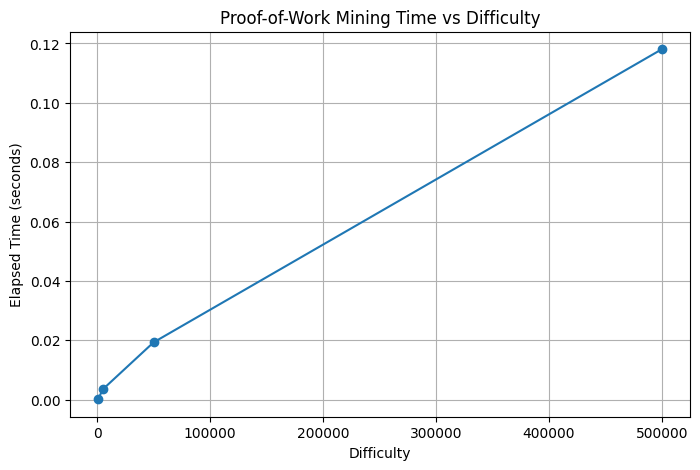

In [ ]:
import hashlib
import secrets
import time
import matplotlib.pyplot as plt

def mine_block(difficulty, block_data=b"UFC Fight: Jon Jones vs Daniel Cormier"):
    max_target = 2**256 - 1
    target = max_target // difficulty

    random_data = secrets.token_bytes(4)
    nonce = 0
    block_found = False
    start = time.time()

    while not block_found:
        input_data = str(nonce).encode() + block_data + random_data
        hash_hex = hashlib.sha256(input_data).hexdigest()
        hash_int = int(hash_hex, 16)

        # Proof-of-work check
        if hash_int < target:
            block_found = True
            end = time.time()
            elapsed = end - start
            return {
                "difficulty": difficulty,
                "target": target,
                "nonce": nonce,
                "hash": hash_hex,
                "elapsed": elapsed
            }
        else:
            nonce += 1

difficulties = [1000, 5000, 50000, 500000]
results = []

for d in difficulties:
    result = mine_block(difficulty=d)
    results.append(result)
    print("\n--- Difficulty:", result["difficulty"], "---")
    print("Nonce:", result["nonce"])
    print("Hash:", result["hash"])
    print("Target:", result["target"])
    print("Elapsed time:", round(result["elapsed"], 6), "seconds")

# Plot elapsed time vs difficulty
plt.figure(figsize=(8, 5))
plt.plot([r["difficulty"] for r in results],
         [r["elapsed"] for r in results],
         marker="o", linestyle="-")

plt.xlabel("Difficulty")
plt.ylabel("Elapsed Time (seconds)")
print()
plt.title("Proof-of-Work Mining Time vs Difficulty")
plt.grid(True)
plt.show()


**Question 2**: Write a script to modify the difficulty every time a block is found faster than expected (increase difficulty) and readjusts if a block is found slower than expected (decrease difficulty).


--- Block 1 ---
Difficulty: 5000
Nonce: 4029
Hash: 00023769daa2f16c9c272b5b8a4a2e6e09eb2b7de5d2bde380f3a0865aab4e9f
Target: 23158417847463239084714197001737581570653996933128112807891516801582625927
Elapsed time: 0.012219 seconds
⏫ Increased difficulty (too fast)

--- Block 2 ---
Difficulty: 6000
Nonce: 2111
Hash: 000270c748d5520558271815d1bcfa4bbec0340abfc88421329abd9d3699db88
Target: 19298681539552699237261830834781317975544997444273427339909597334652188273
Elapsed time: 0.007285 seconds
⏫ Increased difficulty (too fast)

--- Block 3 ---
Difficulty: 7200
Nonce: 9421
Hash: 00014c79d256eb6a265fd3a2a6e15164ef9c970581599ced1ae765f72dc1c964
Target: 16082234616293916031051525695651098312954164536894522783257997778876823561
Elapsed time: 0.032521 seconds
⏫ Increased difficulty (too fast)

--- Block 4 ---
Difficulty: 8640
Nonce: 18520
Hash: 00020249ddf6770fae6a24312a5c8388ad273b1d76a70bd8854fef1a073c2ee0
Target: 13401862180244930025876271413042581927461803780745435652714998149064019634
Elap

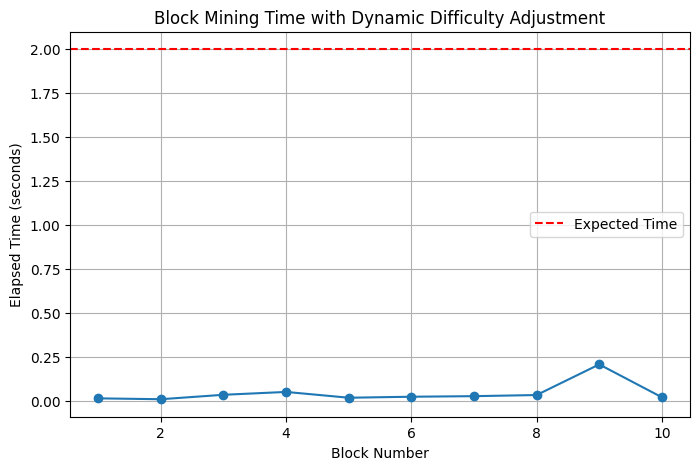

In [ ]:
import hashlib
import secrets
import time
import matplotlib.pyplot as plt

def mine_block(difficulty, block_data=b"UFC Fight: Jon Jones vs Daniel Cormier"):
    max_target = 2**256 - 1
    target = max_target // difficulty

    random_data = secrets.token_bytes(4)
    nonce = 0
    block_found = False
    start = time.time()

    while not block_found:
        input_data = str(nonce).encode() + block_data + random_data
        hash_hex = hashlib.sha256(input_data).hexdigest()
        hash_int = int(hash_hex, 16)

        # Proof-of-work check
        if hash_int < target:
            block_found = True
            end = time.time()
            elapsed = end - start
            return {
                "difficulty": difficulty,
                "target": target,
                "nonce": nonce,
                "hash": hash_hex,
                "elapsed": elapsed
            }
        else:
            nonce += 1


# === Dynamic Difficulty Mining Simulation ===
expected_block_time = 2  # seconds
initial_difficulty = 5000
num_blocks = 10

results = []
difficulty = initial_difficulty

for i in range(1, num_blocks + 1):
    result = mine_block(difficulty=difficulty)
    results.append(result)

    print(f"\n--- Block {i} ---")
    print("Difficulty:", result["difficulty"])
    print("Nonce:", result["nonce"])
    print("Hash:", result["hash"])
    print("Target:", result["target"])
    print("Elapsed time:", round(result["elapsed"], 6), "seconds")

    # Difficulty adjustment
    if result["elapsed"] < expected_block_time:
        difficulty = int(difficulty * 1.2)  # increase by 20%
        print("⏫ Increased difficulty (too fast)")
    elif result["elapsed"] > expected_block_time:
        difficulty = max(1, int(difficulty * 0.8))  # decrease by 20%
        print("⏬ Decreased difficulty (too slow)")
    else:
        print("✅ Difficulty unchanged (on target)")


# === Plot Block Time vs Block Number ===
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(results) + 1),
         [r["elapsed"] for r in results],
         marker="o", linestyle="-")

plt.axhline(expected_block_time, color="red", linestyle="--", label="Expected Time")

plt.xlabel("Block Number")
plt.ylabel("Elapsed Time (seconds)")
plt.title("Block Mining Time with Dynamic Difficulty Adjustment")
print()
plt.legend()
plt.grid(True)
plt.show()

**Question 3**: Can you have a proof of work blockchain with a realtime difficulty adjustment? What are some of the advantages of this setup? Limitations?

Yes you can.

Some of the advantages are that new blocks are found at a consistent rate to make transaction times more predicatble. As well as stops powerful miners from doing "Smash & Grab" mining where they quickly mine blocks for easy profit then leave before the difficulty has a chance to catch up.

However if you designed carefully the difficuly can swing wildy from one block to the next which would make the network unstable and unpredictable. In turn also means its technically harder to build a system that can adjust difficulty smoothly and fairly with every block

## Exercise 2

**Question 1**: Using remix, modify the Storage.sol contract to store and retrieve a text variable: yourName. How much gas does this use, how does this compare to storing an integer?

When storing a string it was ~40,000 gas units, but this was for a single letter when I was doing lengthy strings it was upwards of 70,000+ gas units

When storing an integer however it was roughly only around ~25000 gas units

Apparently its because unit256 is also fixed sized of 32 bytes nd occupies exactly 1 storage slot. However a string has extra gas for storing the hash of the string to act as a pointer. As well as storage of the actual data.


In [ ]:
// SPDX-License-Identifier: MIT
pragma solidity ^0.8.20;

contract Storage {
    string public yourName;  // String storage (dynamic size)
    uint256 public yourNumber; // Integer storage (fixed 32 bytes)

    // Store a name (string)
    function storeName(string memory _name) public {
        yourName = _name;
    }

    // Store a number (uint256)
    function storeNumber(uint256 _number) public {
        yourNumber = _number;
    }
}

**Question 2**: Where is a deployed contract stored in Ethereum? Comment on the different gas costs for a) deploying a contract, b) calling a function, and c) storing an address.

Contracts are stored on-chain in the ethereum state database and each ethereum node replicates and persists this data.

a) Expensive, because you pay for contracts bytecode on chain and the constructor function which can have all sorts of logic. It can cost roughly ~32,000 gas base + 200 gas per byte of contract code.

b) Depends, it can be free if called locally. If there is no gas transaction involved there is no state change. If its state changing it costs gas because it needs to execute instructions and potentially write to storage.

c) Depends, storing data in a fresh storage slot costs ~20,000 gas, while updating an already-used slot costs only ~5,000 gas. To save gas, initialize variables in the constructor and avoid writing to new slots in frequently called functions.

**Question 3**: Above, where it says STORAGE AT 0X...., what does this mean? Are there differences between someone's Ethereum Address and where your contract is stored?

"Storage at 0x.." refers to which storage slot the raw data is stored at in the Deployed contract.

The difference between a users address and contract address has several differences. Such as a users address is generating via private key and is controlled by the user, a contract is deployed by a transaction and is executing via code with no private address. Also a users address can only hold and send ETH, it cannot execute code or store data (aside from token balances)

## Exercise 3

**Question 1**:  What are some examples of fungible tokens compared to non-fungible tokens that you use that are not blockchain related (Tutorial 9)?

Fungible examples could be anything from cash bills, trading cards or stock shares. Non-Fungible could be artwork, real estate, passport or university degrees.

**Question 2**: How much gas did you pay to deploy your contract? What are some implications of the gas auction fees model (Tutorial 9)

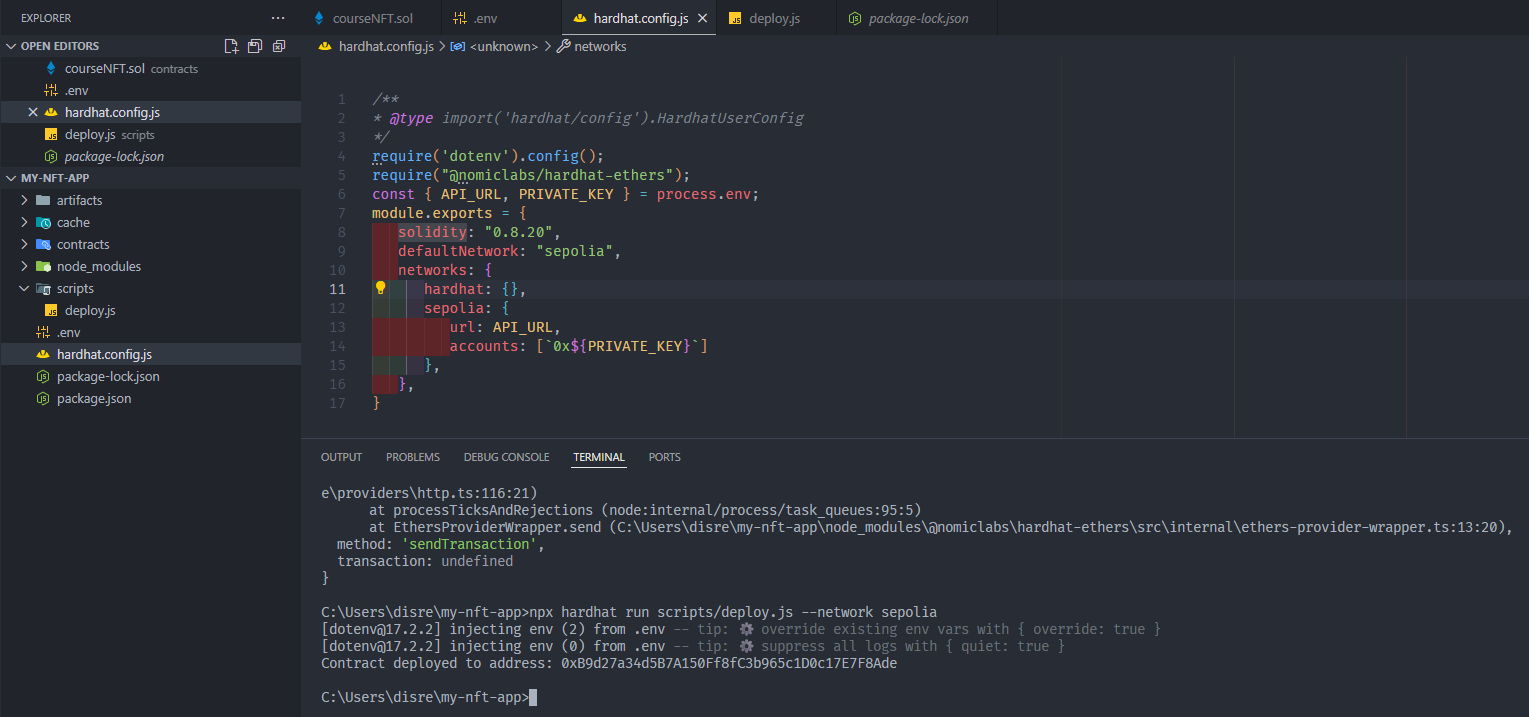

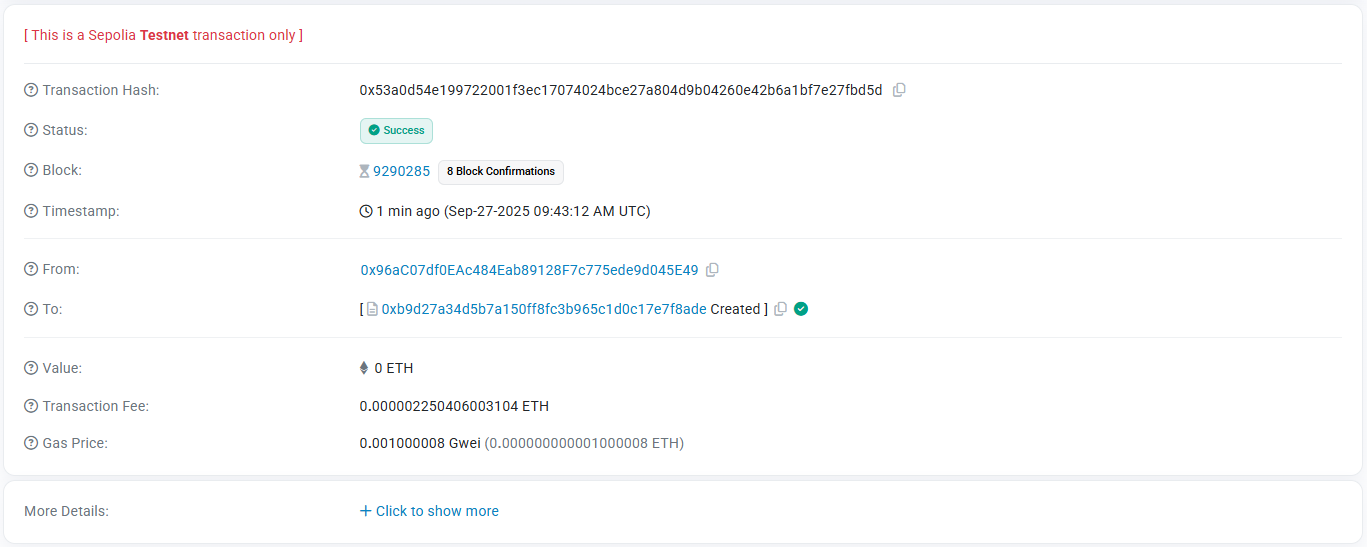

I paid only 0.000002250406003104 ETH to deploy onto the testnet. If it was on the main net it would have been much higher. Probably in the thousands.

Implications of the Gas Auction model causes competition for block space. When demand is high users "bid" more to get transactions included faster. This can cause uncertainty in costs since gas fees will fluctuate depending on congestion. Developers are also motivated to optimize smart contracts to use less gas.

**Question 3**: Change the metadata and mint another NFT

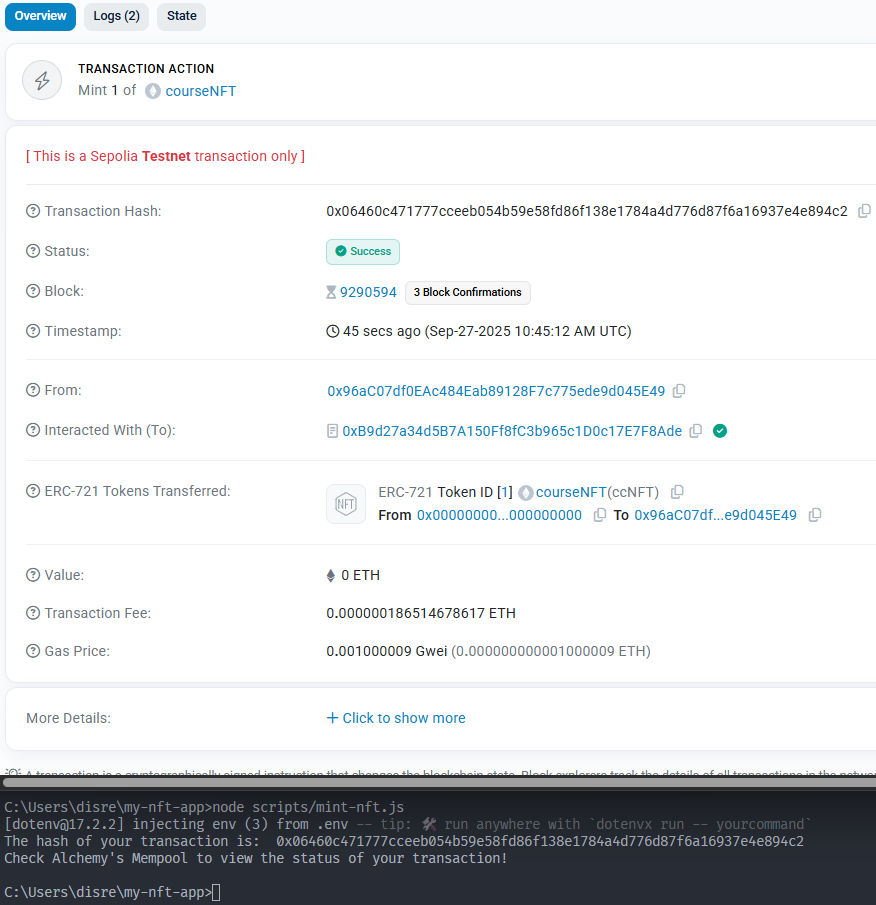

Heres the etherscan transaction info for minting the first NFT with the vscode terminal success message underneath.

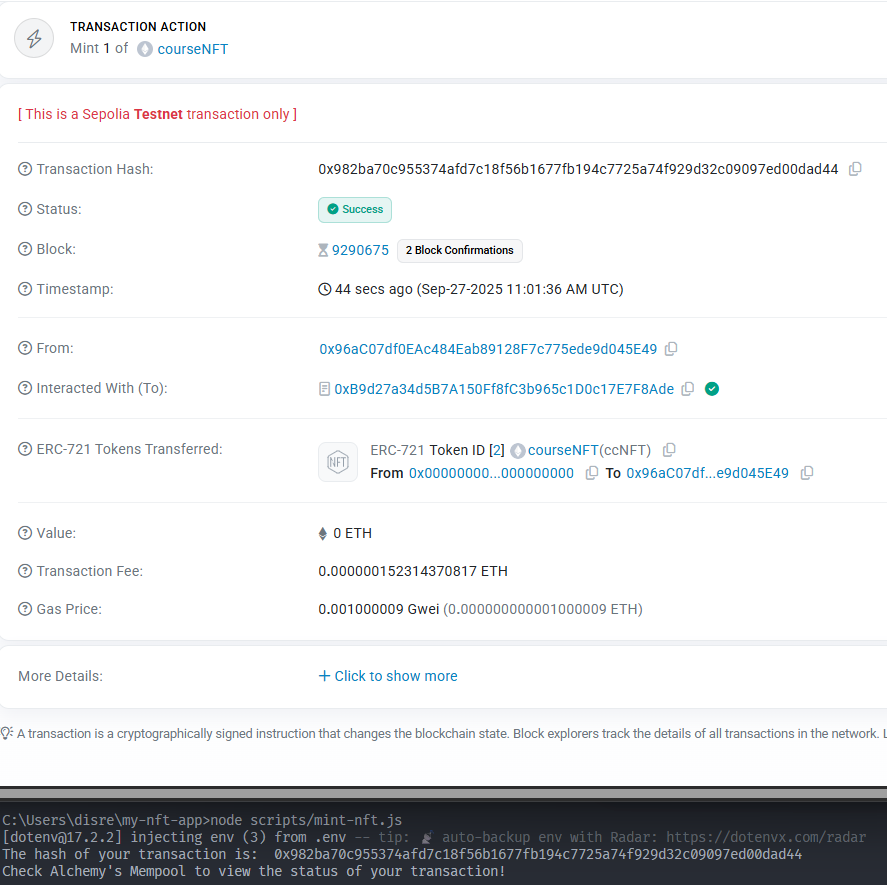

Here is the transaction and vscode terminal message after I have changed the metadata and minted another NFT. Unfortunately I couldn't find a way to view the metadata for each token as OpeaSea no longer supports testnet nft's.

**Question 4**: Write a script to generate a new random NFT every time mint is called (Tutorial 10).

Here is a screen shot of the result. The code file can be found at the bottom of this page.

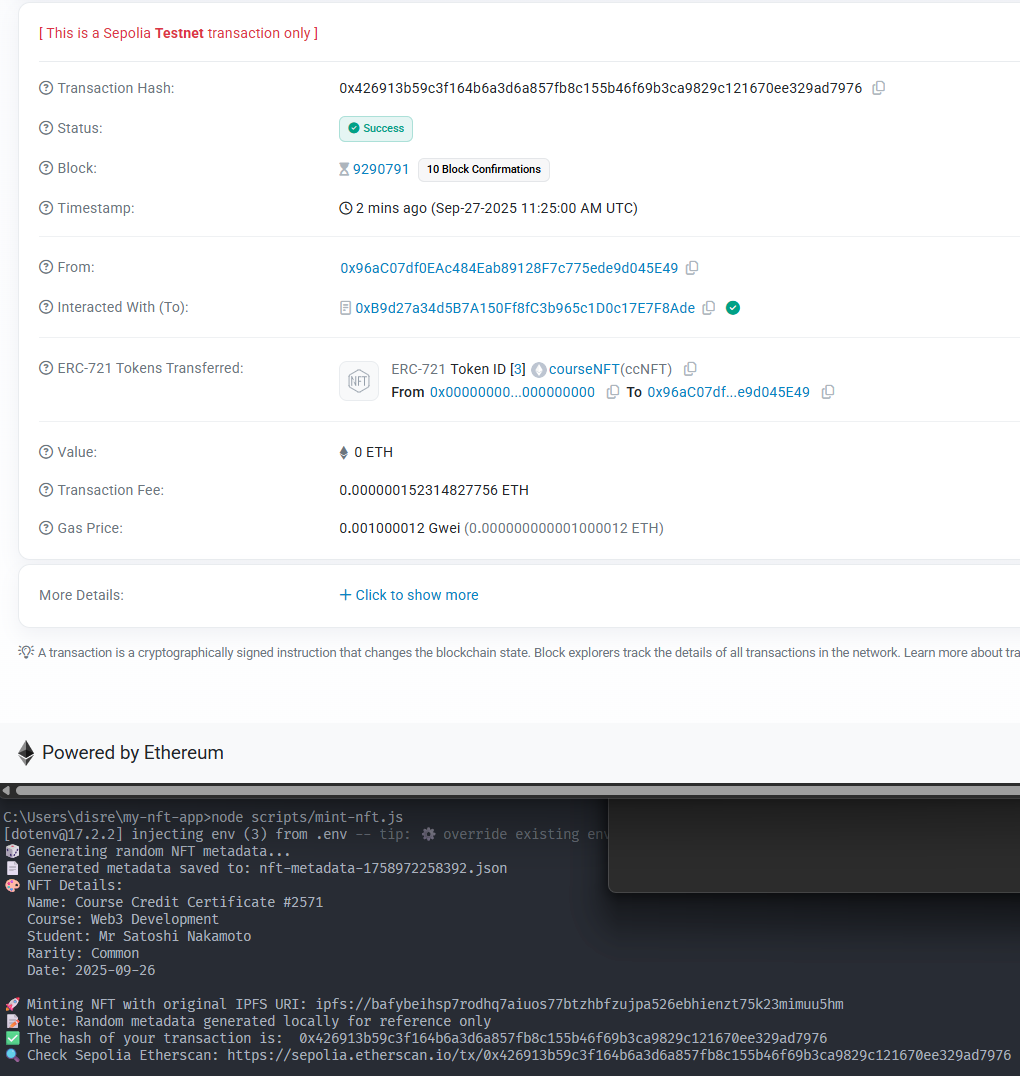

In [ ]:
require("dotenv").config()
const API_URL = process.env.API_URL
const PUBLIC_KEY = process.env.PUBLIC_KEY
const PRIVATE_KEY = process.env.PRIVATE_KEY
const fs = require('fs')
const path = require('path')

const { createAlchemyWeb3 } = require("@alch/alchemy-web3")
const web3 = createAlchemyWeb3(API_URL)
const contract = require("../artifacts/contracts/courseNFT.sol/courseNFT.json")
const contractAddress = "0xB9d27a34d5B7A150Ff8fC3b965c1D0c17E7F8Ade"
const nftContract = new web3.eth.Contract(contract.abi, contractAddress)

// Random NFT generation data
const courses = [
  "Advanced Cryptocurrency",
  "Blockchain Development",
  "Smart Contract Programming",
  "DeFi Fundamentals",
  "NFT Creation",
  "Web3 Development",
  "Ethereum Development",
  "Solidity Mastery",
  "Crypto Trading",
  "Digital Asset Management"
]

const names = [
  "Mr Satoshi Nakamoto",
  "Ms Vitalik Buterin",
  "Dr Charles Hoskinson",
  "Prof Gavin Wood",
  "Ms Cathie Wood",
  "Mr Andreas Antonopoulos",
  "Dr Silvio Micali",
  "Ms Laura Shin",
  "Mr Brian Armstrong",
  "Dr Emin Gün Sirer"
]

const descriptions = [
  "Course Credits Certificate in",
  "Professional Certification for",
  "Advanced Diploma in",
  "Expert Level Achievement in",
  "Mastery Certificate for",
  "Specialized Training in",
  "Professional Development in",
  "Advanced Studies Certificate in"
]

const rarityLevels = ["Common", "Uncommon", "Rare", "Epic", "Legendary"]
const completionDates = ["2025-09-27", "2025-09-26", "2025-09-25", "2025-09-24", "2025-09-23"]

const metadataURIs = [
  "ipfs://bafybeihsp7rodhq7aiuos77btzhbfzujpa526ebhienzt75k23mimuu5hm",
]

function getRandomElement(array) {
  return array[Math.floor(Math.random() * array.length)]
}

function generateRandomMetadata() {
  const course = getRandomElement(courses)
  const name = getRandomElement(names)
  const description = getRandomElement(descriptions)
  const rarity = getRandomElement(rarityLevels)
  const completionDate = getRandomElement(completionDates)
  const tokenId = Math.floor(Math.random() * 10000) + 1

  const metadata = {
    name: `Course Credit Certificate #${tokenId}`,
    description: `${description} ${course}`,
    image: "ipfs://bafybeihsp7rodhq7aiuos77btzhbfzujpa526ebhienzt75k23mimuu5hm",
    attributes: [
      {
        trait_type: "Course",
        value: course
      },
      {
        trait_type: "Student Name",
        value: name
      },
      {
        trait_type: "Rarity",
        value: rarity
      },
      {
        trait_type: "Completion Date",
        value: completionDate
      },
      {
        trait_type: "Token ID",
        value: tokenId
      }
    ]
  }

  return metadata
}

function saveMetadataToFile(metadata) {
  const filename = `nft-metadata-${Date.now()}.json`
  const filepath = path.join(__dirname, '..', filename)

  fs.writeFileSync(filepath, JSON.stringify(metadata, null, 2))
  console.log(`📄 Generated metadata saved to: ${filename}`)
  console.log(`🎨 NFT Details:`)
  console.log(`   Name: ${metadata.name}`)
  console.log(`   Course: ${metadata.attributes[0].value}`)
  console.log(`   Student: ${metadata.attributes[1].value}`)
  console.log(`   Rarity: ${metadata.attributes[2].value}`)
  console.log(`   Date: ${metadata.attributes[3].value}`)

  return filepath
}

async function mintRandomNFT() {
  console.log("🎲 Generating random NFT metadata...")

  // Generate random metadata
  const metadata = generateRandomMetadata()

  // Save metadata to file (for your records)
  const metadataFile = saveMetadataToFile(metadata)

  // Use a random pre-defined IPFS URI (simulating different metadata)
  const randomURI = getRandomElement(metadataURIs)

  console.log(`\n🚀 Minting NFT with URI: ${randomURI}`)

  const nonce = await web3.eth.getTransactionCount(PUBLIC_KEY, 'latest');

  const tx = {
    'from': PUBLIC_KEY,
    'to': contractAddress,
    'nonce': nonce,
    'gas': 500000,
    'data': nftContract.methods.mintNFT(PUBLIC_KEY, randomURI).encodeABI()
  };

  const signPromise = web3.eth.accounts.signTransaction(tx, PRIVATE_KEY)
  signPromise
    .then((signedTx) => {
      web3.eth.sendSignedTransaction(
        signedTx.rawTransaction,
        function (err, hash) {
          if (!err) {
            console.log(
              "✅ The hash of your transaction is: ",
              hash,
              "\n🔍 Check Sepolia Etherscan: https://sepolia.etherscan.io/tx/" + hash
            )
          } else {
            console.log(
              "❌ Something went wrong when submitting your transaction:",
              err
            )
          }
        }
      )
    })
    .catch((err) => {
      console.log("💥 Promise failed:", err)
    })
}

// Function to mint multiple NFTs
async function mintMultipleNFTs(count = 1) {
  for (let i = 0; i < count; i++) {
    console.log(`\n🎯 Minting NFT ${i + 1} of ${count}`)
    await mintRandomNFT()

    // Add delay between mints to avoid nonce issues
    if (i < count - 1) {
      console.log("⏳ Waiting 10 seconds before next mint...")
      await new Promise(resolve => setTimeout(resolve, 10000))
    }
  }
}

// Check command line arguments
const args = process.argv.slice(2)
const command = args[0]
const count = parseInt(args[1]) || 1

if (command === 'multiple') {
  console.log(`🚀 Starting batch mint of ${count} NFTs...`)
  mintMultipleNFTs(count)
} else {
  // Run single random NFT minter
  mintRandomNFT()
}